# Prelim graphs
1. Raw counts
2. Outlier detection for crime count per month

In [2]:
import geopandas as gpd
import sqlite3
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import libpysal
import seaborn as sns

conn = sqlite3.connect('../data/wales_data.db')
cursor = conn.cursor()

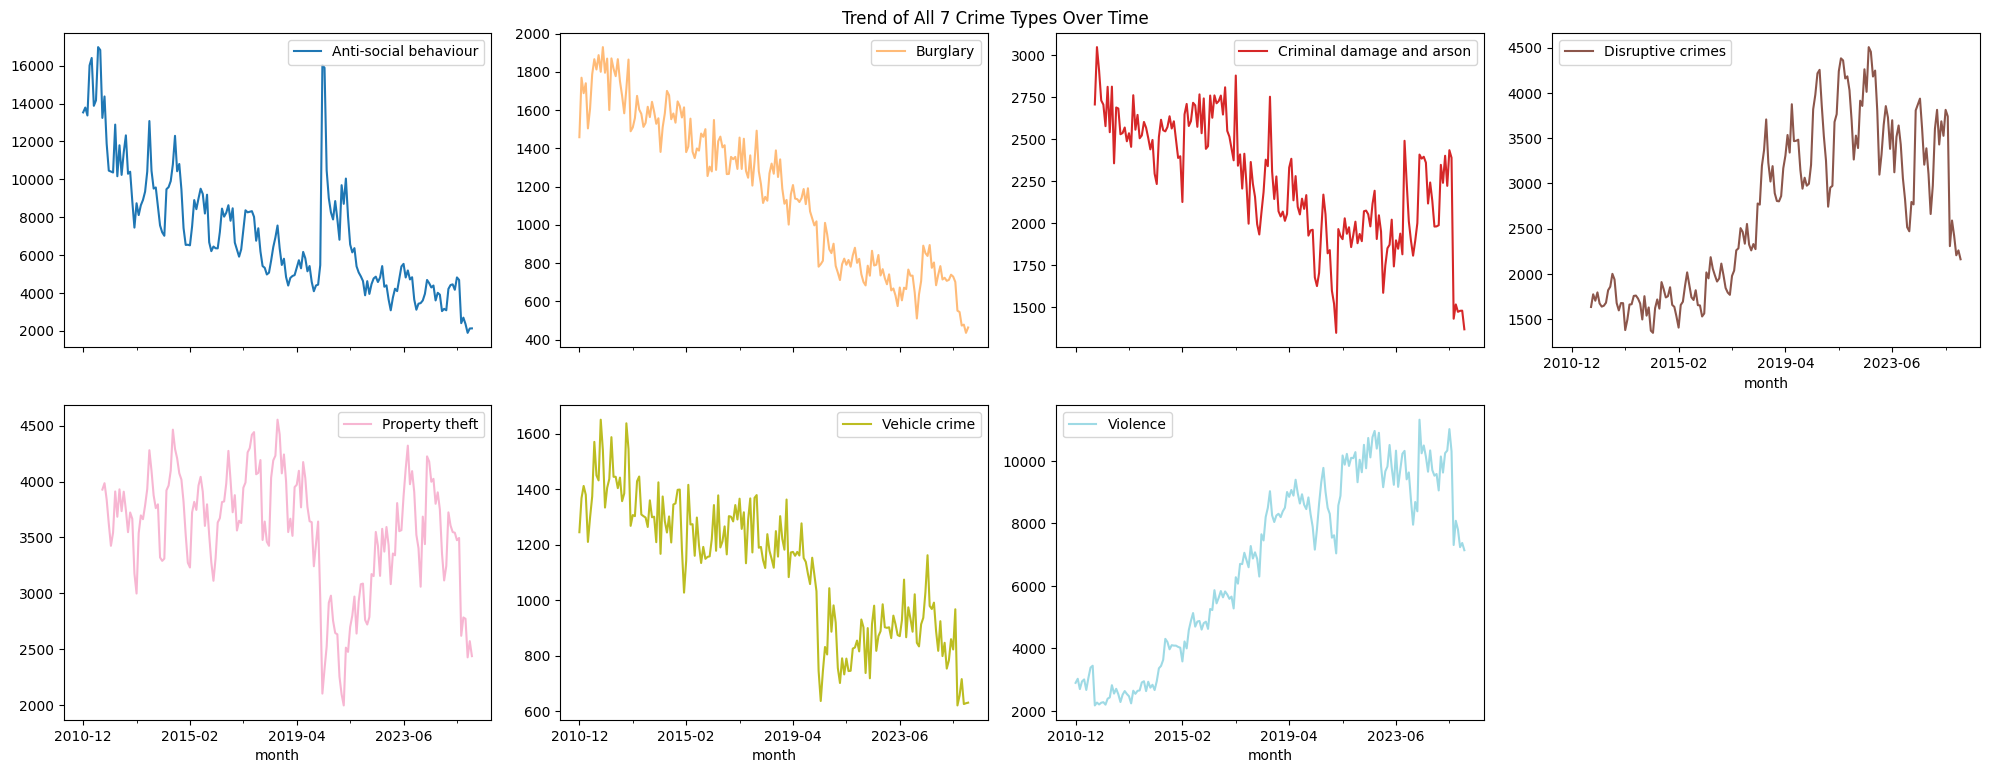

In [3]:
#1 Graph raw counts against time per combined crime type

#query total counts per month per combined crime type
query = """
SELECT month, crime_type, COUNT(*) as incident_count
FROM street_crimes
GROUP BY month, crime_type
ORDER BY month;
"""
df = pd.read_sql(query, conn)

#turns month into index and creates 7 cols of crime counts
df_pivot = df.pivot(index='month', columns='crime_type', values='incident_count')

#plotting all 7
ax = df_pivot.plot(
    subplots=True,
    layout=(4, 4),
    figsize=(20, 15),
    sharex=True,
    colormap= "tab20",
    title="Trend of All 7 Crime Types Over Time"
)
plt.tight_layout()
plt.savefig('../data/crime_trends_Wales.png', dpi=300, bbox_inches='tight')
plt.show()

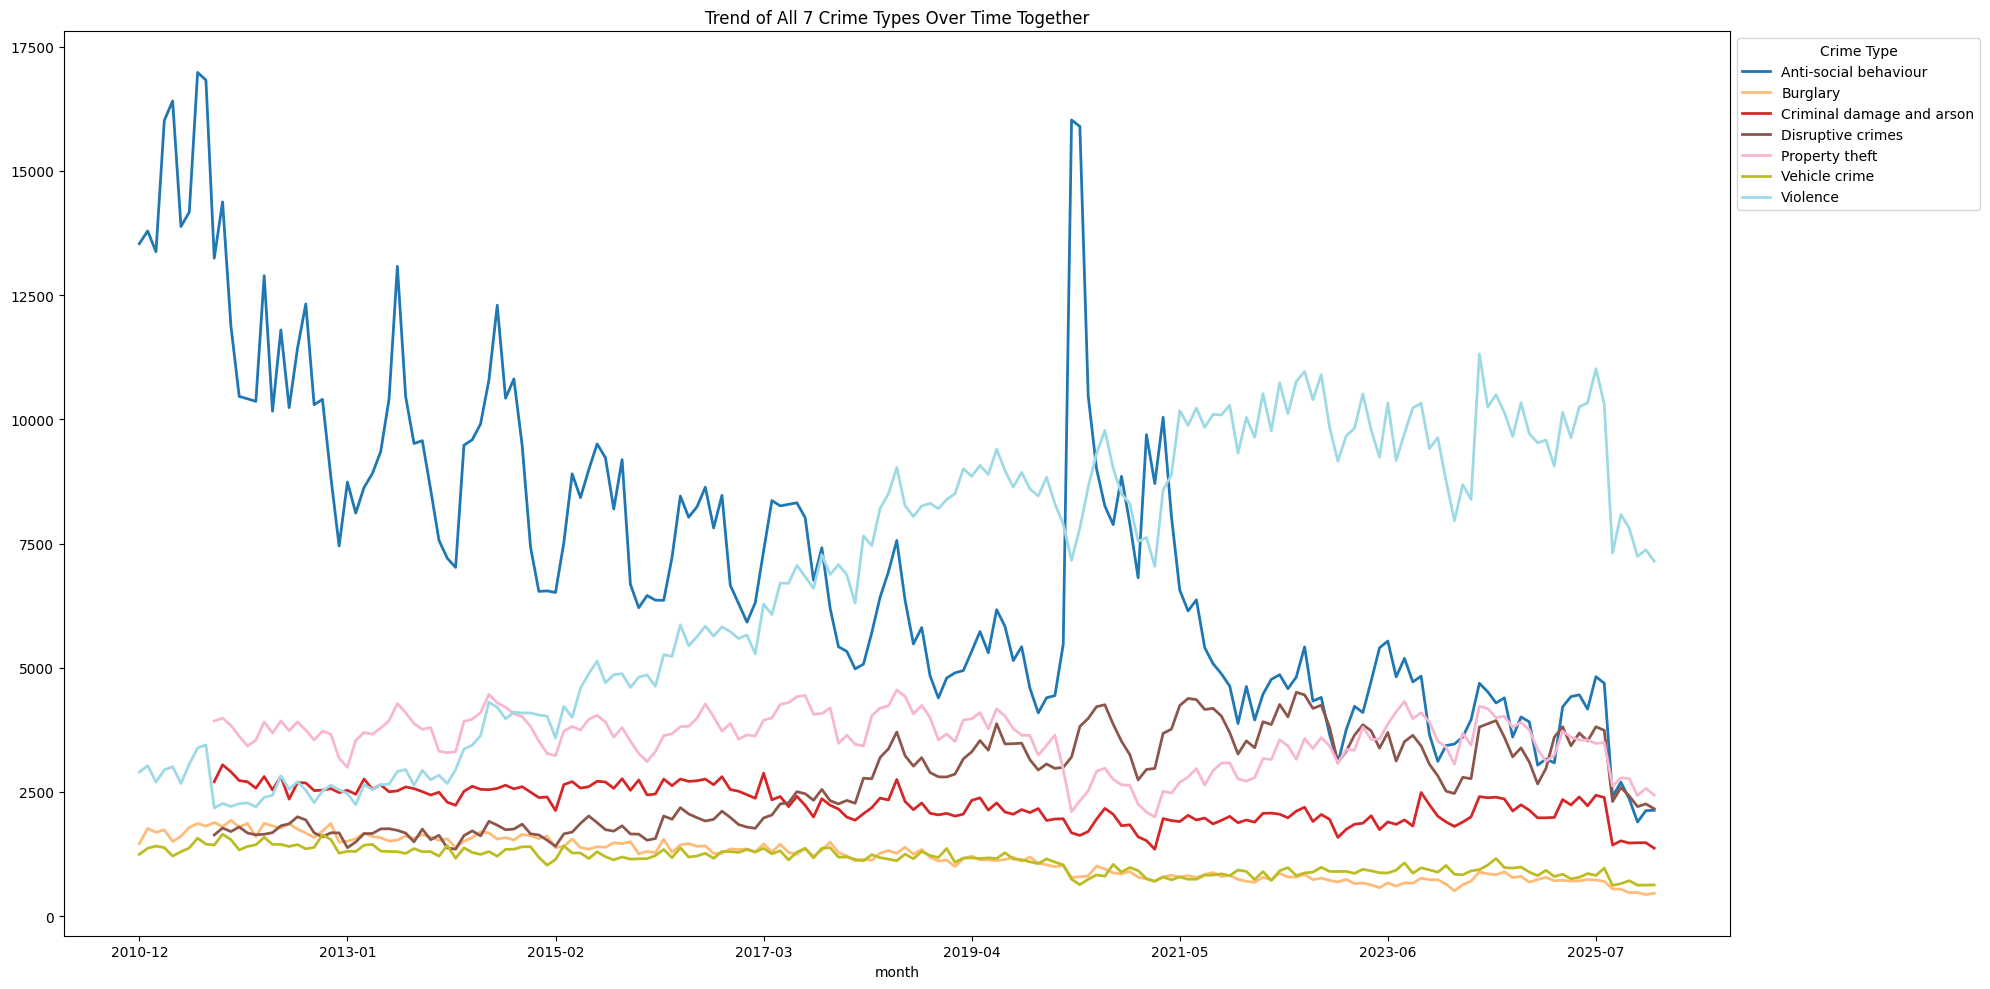

In [4]:
#1a Big graph (same thing as before just subplots not on)

ax = df_pivot.plot(
    figsize=(20, 10),
    colormap="tab20",
    linewidth=2,
    title="Trend of All 7 Crime Types Over Time Together"
)

plt.legend(title='Crime Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../data/crime_trends_combined_Wales.png', dpi=300, bbox_inches='tight')
plt.show()

Pulling and aggregating total crimes per LSOA...

--- Distribution Summary Table ---


,Total Crimes per Month
count,350628.00
mean,12.71
std,18.71
min,0.00
25%,5.00
50%,9.00
75%,16.00
max,870.00


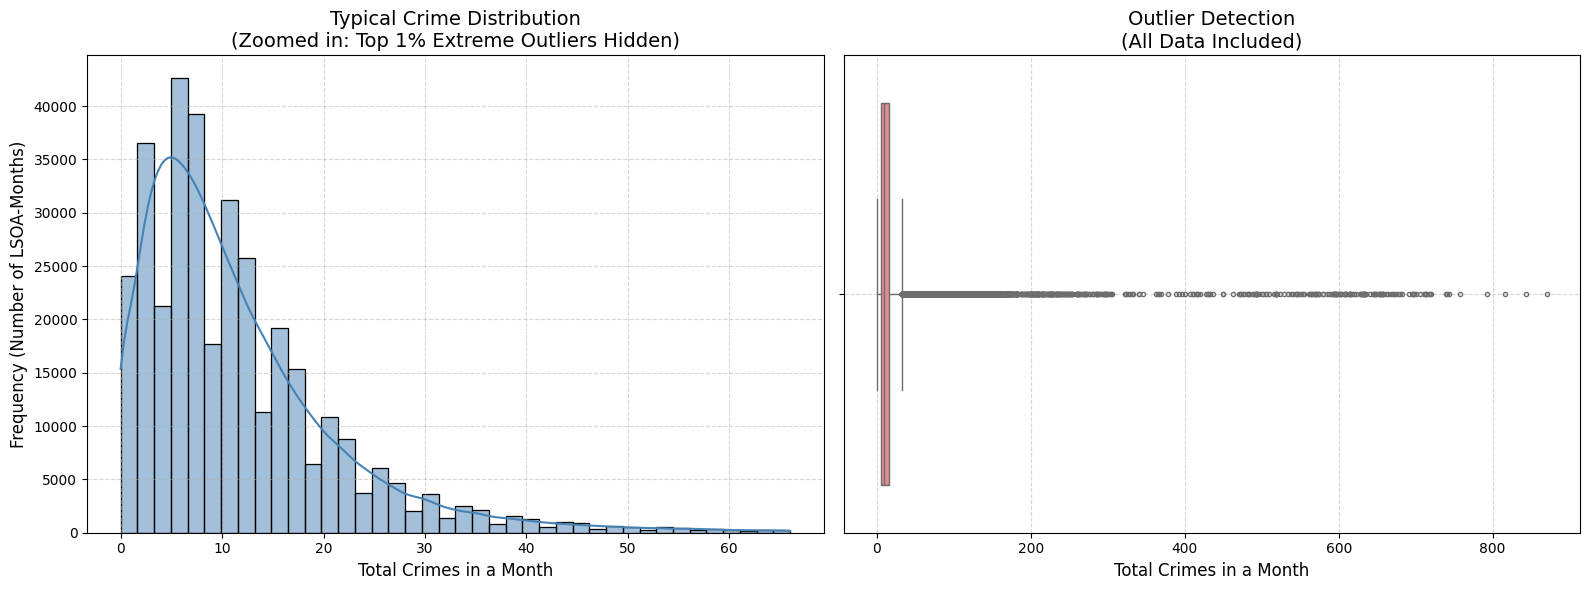

In [5]:
#2; done w/ gemini; checking distributions

print("Pulling and aggregating total crimes per LSOA...")
# 1. Sum up all crime types to get the TOTAL crimes per LSOA per month
query = """
SELECT lsoa_code, month, SUM(crime_count) as total_monthly_crimes
FROM lsoa_month
GROUP BY lsoa_code, month;
"""
df_totals = pd.read_sql(query, conn)

# 2. Create the Summary Table
# describe() automatically calculates the mean, median, percentiles, and outliers
summary_table = df_totals['total_monthly_crimes'].describe().to_frame(name='Total Crimes per Month')
summary_table = summary_table.round(2)

print("\n--- Distribution Summary Table ---")
display(summary_table)

# 3. Create the Graphs
# We set up a 1x2 grid so we can see the distribution and the outliers side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: The Histogram (The "Normal" Distribution) ---
# Extreme outliers ruin histograms, so we calculate the 99th percentile and temporarily hide the top 1% just for this graph
p99 = df_totals['total_monthly_crimes'].quantile(0.99)
normal_data = df_totals[df_totals['total_monthly_crimes'] <= p99]

sns.histplot(data=normal_data, x='total_monthly_crimes', bins=40, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Typical Crime Distribution\n(Zoomed in: Top 1% Extreme Outliers Hidden)', fontsize=14)
ax1.set_xlabel('Total Crimes in a Month', fontsize=12)
ax1.set_ylabel('Frequency (Number of LSOA-Months)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: The Boxplot (The Outlier Detector) ---
# We use the FULL dataset here. Every dot outside the main box is a statistical outlier.
sns.boxplot(data=df_totals, x='total_monthly_crimes', ax=ax2, color='lightcoral', fliersize=3)
ax2.set_title('Outlier Detection\n(All Data Included)', fontsize=14)
ax2.set_xlabel('Total Crimes in a Month', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
#2a done w gemini; finding the outliers

print("Hunting down the extreme outliers...")

# This query finds any neighborhood/month combo that has over 800 crimes, 
# and shows us exactly how that number was built.
query = """
WITH Massive_Months AS (
    SELECT lsoa_code, month, SUM(crime_count) as total_crimes
    FROM lsoa_month
    GROUP BY lsoa_code, month
    HAVING SUM(crime_count) > 800  -- Adjust this threshold if needed
)
SELECT 
    m.lsoa_code, 
    m.month, 
    m.total_crimes,
    l.crime_type,
    l.crime_count
FROM Massive_Months m
JOIN lsoa_month l 
  ON m.lsoa_code = l.lsoa_code AND m.month = l.month
ORDER BY m.total_crimes DESC, m.lsoa_code, m.month, l.crime_count DESC
LIMIT 30;
"""

outliers_df = pd.read_sql(query, conn)

display(outliers_df)

Hunting down the extreme outliers...


,lsoa_code,month,total_crimes,crime_type,crime_count
0,W01002019,2017-11,870,Property theft,375
1,W01002019,2017-11,870,Anti-social behaviour,232
2,W01002019,2017-11,870,Violence,158
3,W01002019,2017-11,870,Disruptive crimes,61
4,W01002019,2017-11,870,Criminal damage and arson,24
5,W01002019,2017-11,870,Vehicle crime,12
6,W01002019,2017-11,870,Burglary,8
7,W01002019,2011-12,843,Property theft,399
8,W01002019,2011-12,843,Anti-social behaviour,223
9,W01002019,2011-12,843,Violence,86


Aggregating raw street crimes per LSOA...

--- Distribution Summary Table (From Raw Data) ---


,Total Crimes per Month (Raw)
count,338249.00
mean,13.18
std,18.89
min,1.00
25%,5.00
50%,9.00
75%,16.00
max,870.00


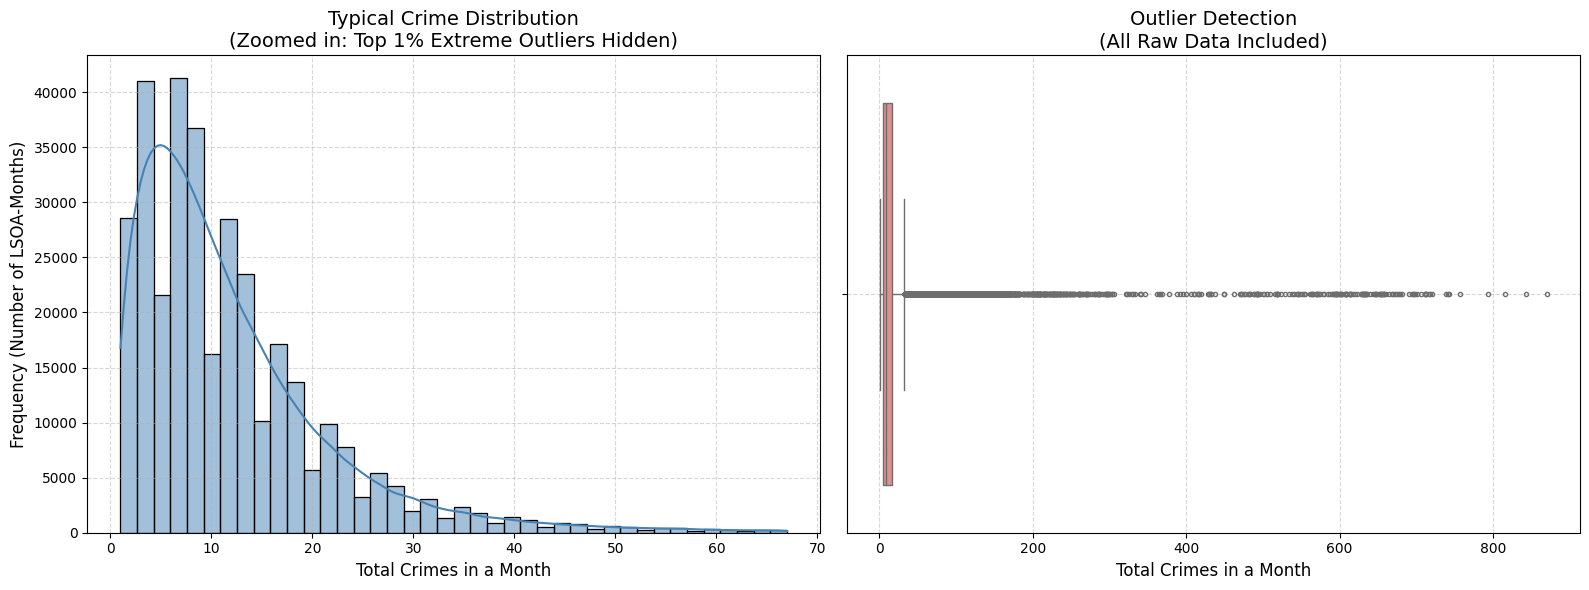

In [7]:
#2b done w gemini ; checking the raw data

print("Aggregating raw street crimes per LSOA...")
# 1. Count the raw rows to get the TOTAL crimes per LSOA per month
query = """
SELECT lsoa_code, month, COUNT(*) as total_monthly_crimes
FROM street_crimes
GROUP BY lsoa_code, month;
"""
df_totals = pd.read_sql(query, conn)

# 2. Create the Summary Table
summary_table = df_totals['total_monthly_crimes'].describe().to_frame(name='Total Crimes per Month (Raw)')
summary_table = summary_table.round(2)

print("\n--- Distribution Summary Table (From Raw Data) ---")
display(summary_table)

# 3. Create the Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: The Histogram (The "Normal" Distribution) ---
p99 = df_totals['total_monthly_crimes'].quantile(0.99)
normal_data = df_totals[df_totals['total_monthly_crimes'] <= p99]

sns.histplot(data=normal_data, x='total_monthly_crimes', bins=40, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Typical Crime Distribution\n(Zoomed in: Top 1% Extreme Outliers Hidden)', fontsize=14)
ax1.set_xlabel('Total Crimes in a Month', fontsize=12)
ax1.set_ylabel('Frequency (Number of LSOA-Months)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: The Boxplot (The Outlier Detector) ---
sns.boxplot(data=df_totals, x='total_monthly_crimes', ax=ax2, color='lightcoral', fliersize=3)
ax2.set_title('Outlier Detection\n(All Raw Data Included)', fontsize=14)
ax2.set_xlabel('Total Crimes in a Month', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
conn.close()